# Policy Based Methods

Up to now, the methods we have discussed are **value-based methods**. These algorithms learn the values of actions (or state–action pairs) and then derive the policy by selecting the actions with the highest estimated value. The policy depends on the value function estimates, without those the policy would not exist.

A different family of methods, called **policy-based methods**, take a more direct approach: they learn a parameterized policy that maps states to actions without consulting a value function ([Sutton et al., **"Policy Gradient Methods for Reinforcement Learning with Function Approximation"**, NIPS, 2000](./papers/1999%20-%20Policy%20Gradient%20Methods%20for%20Reinforcement%20Learning%20with%20Function%20Approximation.pdf)). The policy is written as:

$\displaystyle \pi_\theta(a|s)$

The goal is to **maximize a performance measure** $J(\theta)$ with respect to these parameters:

$\displaystyle \theta_{t+1} = \theta_t + \alpha \nabla_\theta J(\theta_t)$


The only essential requirement for a policy parameterization is that **it must be differentiable** with respect to $\theta4, allowing gradient-based optimization.

In practice, to ensure sufficient exploration, it is important that the policy **does not collapse into a purely deterministic mapping**. A common choice is to parameterize it as a **softmax distribution** over action preferences, which assigns a probability to each action while still favoring those with higher estimated preference:

$\displaystyle \pi_\theta(a|s) = \frac{e^{h(s,a,\theta)}}{\sum_{b} e^{h(s,b, \theta)}}$

where $h(s, a, \theta)$ is the **preference function** for actions in states. It might be computed by a neural network, where the parameter is the vector of all the connection weights of the network, or it could simply be a linear function.

## Objective function

It is natural to define the performance measure as the **expected discounted return from the initial state**: 

$\displaystyle J(\theta) = E_{s_0 \sim p_0 } [G_{\pi_{\theta}}] $

where $p_0$ is the distribution of the initial state, and $G_{\pi_{\theta}}$ is the total discounted return obtained under policy $\pi_{\theta}$.

Learning **stochastic policies directly** has several advantages. They often achieve **better performance in partially observable environments**, since they can hedge decisions across states that appear identical under limited observations. Moreover, exploration is embedded in the learned function itself. In addition, learning a policy can be simpler than learning a value function, since estimating exact state or action values may be unnecessarily complex.

We can now **learn stochastic policies directly**, which often achieve better performance in partially observable environments. The key intuition is that by learning arbitrary action probabilities, the agent is not forced to rely strictly on the Markov assumption. In other words, when the agent cannot fully distinguish between different underlying states based on its observations, a deterministic policy may fail. In such cases, the optimal behavior is often to act randomly but with carefully chosen probabilities, allowing the agent to hedge its decisions across indistinguishable situations. Consider the foggy lake environment:

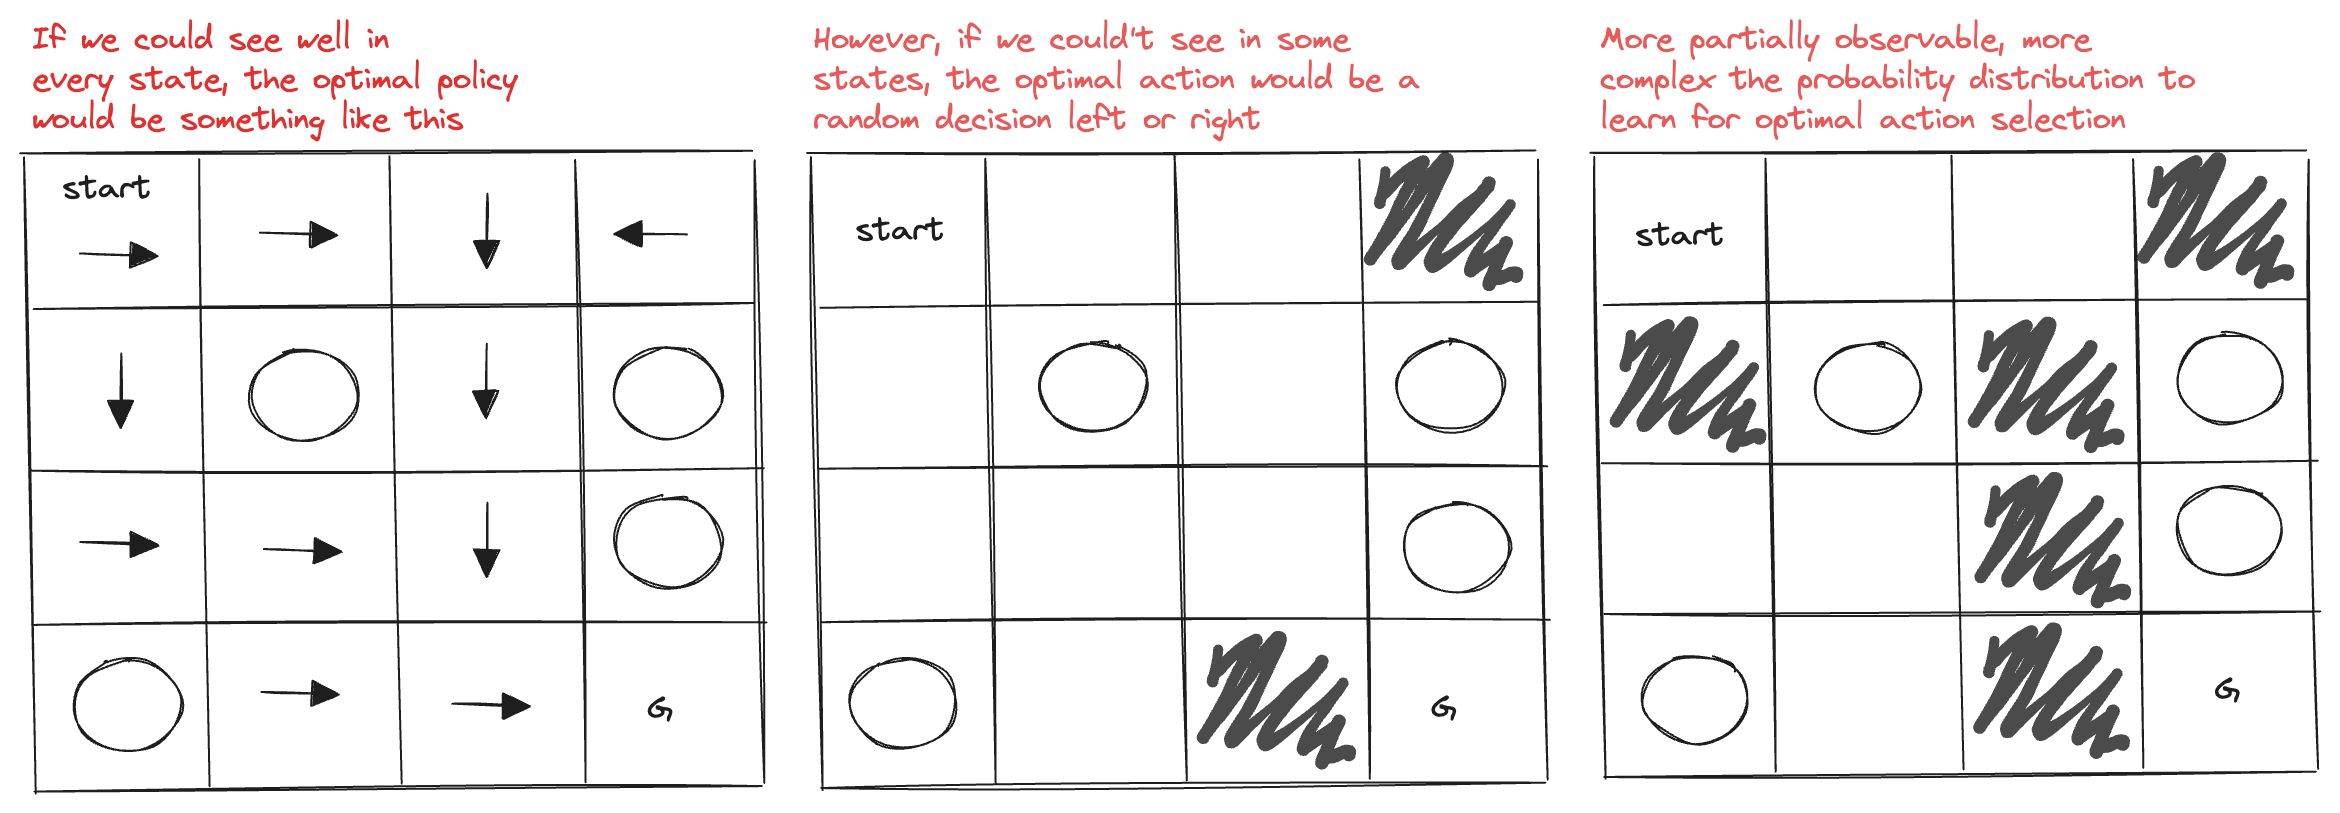

Interestingly, with stochastic policies, **exploration can be embedded in the learned function** Moreover, learning stochastic policies could be **more straightforward for function approximation**. Sometimes value functions are **too much informative** for what’s truly needed. It could be that calculating the exact value of a state or state-action pair is complicated or unnecessary. For example, consider a near-infinite corridor deterministic environment:

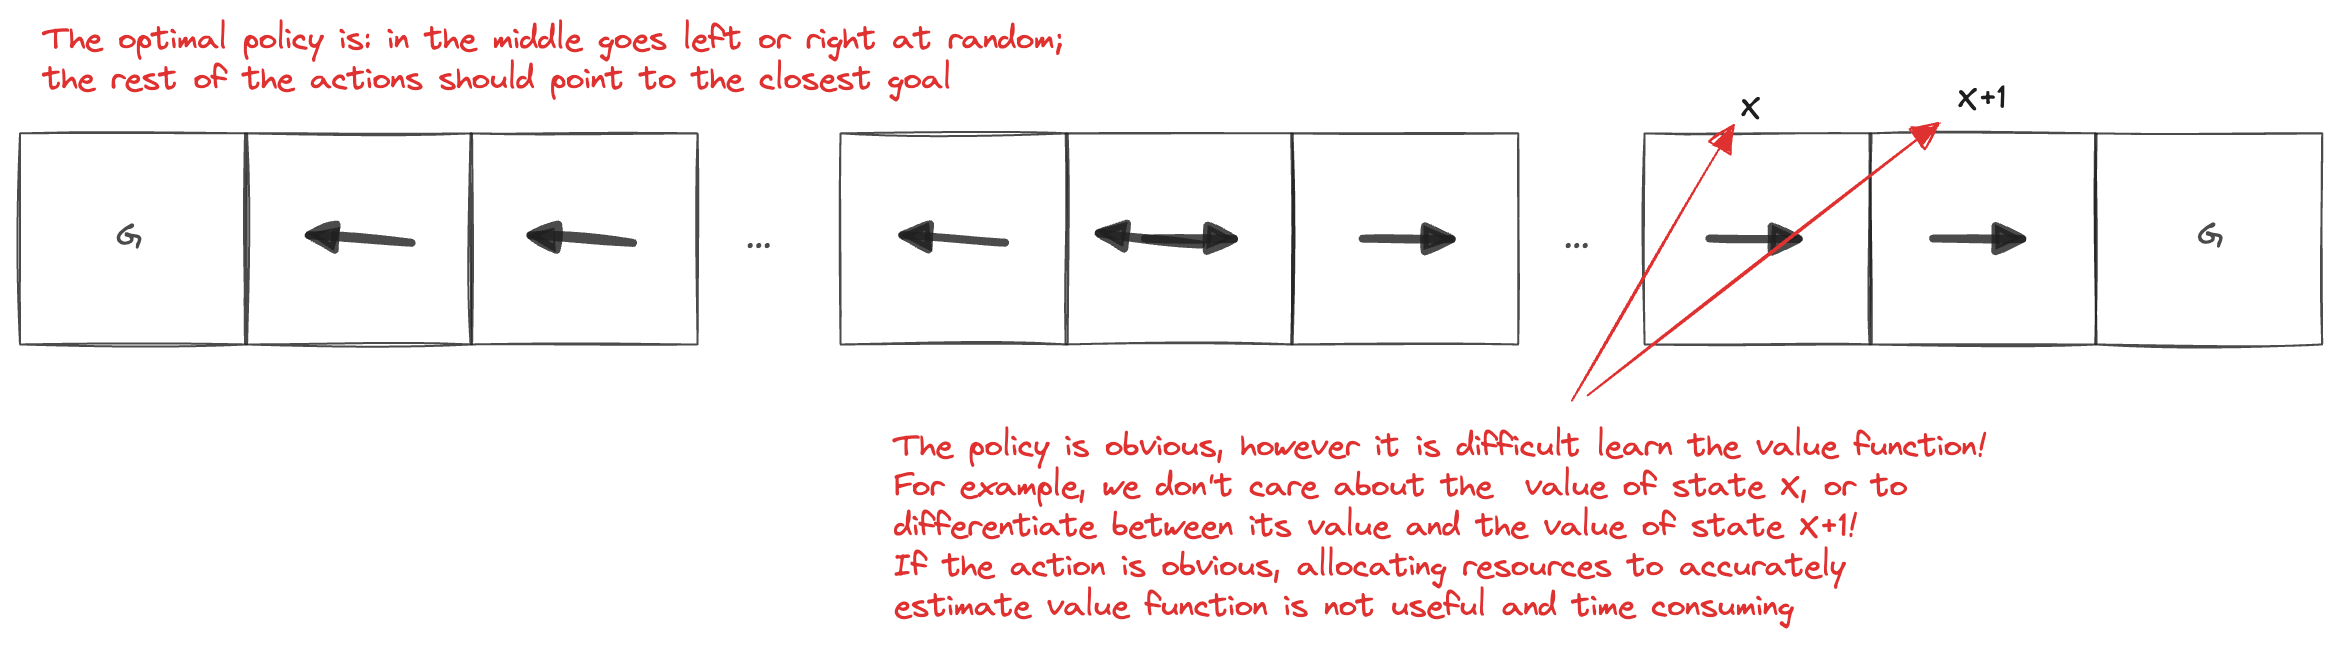

Finally, value-based methods are **prone to oscillations and even divergence**, because small changes in the value function can translate into large, discontinuous shifts in the chosen actions. Such abrupt changes may lead the agent to follow entirely different trajectories, amplifying instability. By contrast, policy-based methods optimize the parameters of a stochastic policy directly through gradient ascent. This results in **actions being adjusted gradually and smoothly**, which often gives policy-based methods **more stable and reliable convergence** properties.

### Policy Gradient Theorem

To improve a policy directly, we need a way to adjust its parameters so that performance improves. This requires computing the **gradient of the performance measure** with respect to the policy parameters: 

$\displaystyle \nabla_\theta J(\theta) = \nabla_\theta E_{s_0 \sim p_0 } [G_{\pi_{\theta}}] $

Let’s introduce the variable $\tau$ to denote a trajectory from a starting state following the policy:

$\displaystyle \tau = (S_0, A_0, R_1, S_1,..., S_{T-1}, A_{T-1}, R_T, S_T)$

and define its return as:

$G(\tau) = R_1 + \gamma R_2 + \cdots + \gamma^{T-1} R_T$

we can express the performance measure as the expected return over all possible trajectories:

$\displaystyle J(\theta) = E_{\tau \sim \pi_\theta } \left[ G(\tau) \right]$

The **probability of a trajectory** under the policy is given by:

$\displaystyle p(\tau|\pi_\theta) = p_0(S_0) \pi_\theta(A_0|S_0) P(S_1|S_0,A_0) \pi_\theta(A_1|S_1)P(S_2|S_1,A_1)...P(S_T|S_{T-1},A_{T-1}) =$

$\displaystyle = p_0(S_0)\prod\limits_{t=0}^{T-1}{P(S_{t+1}|S_t,A_t)\pi_\theta(A_t|S_t)} $

Using this notation, we can rewrite the objective as:

$\displaystyle J(\theta) = E_{\tau \sim \pi_\theta } \left[ G(\tau) \right] = \sum\limits_{\tau} p(\tau|\pi_\theta) G(\tau)$

Taking the gradient of this expression, we obtain:

$\displaystyle \nabla_\theta J(\theta) = \nabla_\theta \sum\limits_{\tau}{p(\tau|\pi_\theta)G(\tau)} $

We can't compute it exactly, because we don't have complete knowledge of the problem. It is a mix of factors that are under our control via the parameters (policy) and factors that are not known (transition probabilities and initial distribution). We can provide an estimation of the gradient, making some mathematical manipulations to remove the unknown factors. first, we can rewrite the gradient of the sum as the sum of the gradient:

$\displaystyle \nabla_\theta J(\theta) = \sum\limits_{\tau}{\nabla_\theta p(\tau|\pi_\theta)G(\tau)} = $

Multiplying and dividing by $p(\tau\mid\pi_\theta)$, we obtain the **likelihood ratio** form:

$\displaystyle = \sum\limits_{\tau}{p(\tau|\pi_\theta) \frac{ \nabla_\theta p(\tau|\pi_\theta)}{p(\tau|\pi_\theta)} G(\tau)} = $

a mathematical result states that the gradient of a function divided by the function itself is equal to the gradient of the log of the function:

$\displaystyle = \sum\limits_{\tau}{p(\tau|\pi_\theta) \nabla_\theta \log p(\tau|\pi_\theta) G(\tau)} =$

$\displaystyle = E_{\tau \sim \pi_\theta } \left[ \nabla_\theta \log p(\tau|\pi_\theta) G(\tau) \right] = $

Substituting the definition of the transition probability:

$\displaystyle = E_{\tau \sim \pi_\theta } \left[ \nabla_\theta \log \left( p_0(S_0)\prod\limits_{t=0}^{T-1}{P(S_{t+1}|S_t,A_t)\pi_\theta(A_t|S_t)} \right) G(\tau) \right] = $


Substituting the log of the product with the sum of the logs:

$\displaystyle = E_{\tau \sim \pi_\theta } \left[ \nabla_\theta \left( \log p_0(S_0) + \sum\limits_{t=0}^{T-1}{\log P(S_{t+1}|S_t,A_t)} + \sum\limits_{t=0}^{T-1}{\log \pi_\theta(A_t|S_t)} \right) G(\tau) \right] = $

Substituting the gradient of the sum with the sum of gradients:

$\displaystyle = E_{\tau \sim \pi_\theta } \left[ \left ( \nabla_\theta \log p_0(S_0) + \nabla_\theta \sum\limits_{t=0}^{T-1}{\log P(S_{t+1}|S_t,A_t)}  + \nabla_\theta \sum\limits_{t=0}^{T-1}{\log \pi_\theta(A_t|S_t)} \right ) G(\tau) \right] = $

Neither initial state distribution or state transition dynamics are dependent of the policy parameters, so the derivate of both terms can be removed:

$\displaystyle = E_{\tau \sim \pi_\theta } \left[ \nabla_\theta \sum\limits_{t=0}^{T-1}{\log \pi_\theta(A_t|S_t)} G(\tau) \right] = $

Substituting the gradient of the sum with the sum of gradients:

$\displaystyle = E_{\tau \sim \pi_\theta } \left[ \sum\limits_{t=0}^{T-1}{\nabla_\theta \log \pi_\theta(A_t|S_t)} G(\tau) \right] $

Finally, estimating the expectation with the mean over several trajectories, we obtain the **policy gradient theorem** that allow us to estimate the gradient using trajectory samples:

$\displaystyle \nabla_\theta J(\theta) = \frac{1}{m}\sum\limits_{i=1}^{m}{ \sum\limits_{t=0}^{T-1}{\nabla_\theta \log \pi_\theta(a_t^{(i)}|s_t^{(i)})} G(\tau^{(i)})} $

The resulting formulation provides a practical means to estimate the policy gradient without access to the transition model. In practice, we collect several complete trajectories by following the current policy, compute for each the total discounted return, and then use this return to weight the log-probabilities of all the actions taken along that trajectory when updating the policy parameters.

### Causality

Considering the policy gradient theorem formulation, we use the total return of the trajectory to weight the log-probabilities of all the actions taken along that trajectory. However, it is better to use only the **causal reward** that come after each action, because we know we can’t go back in time and current actions cannot be responsible for past reward: 

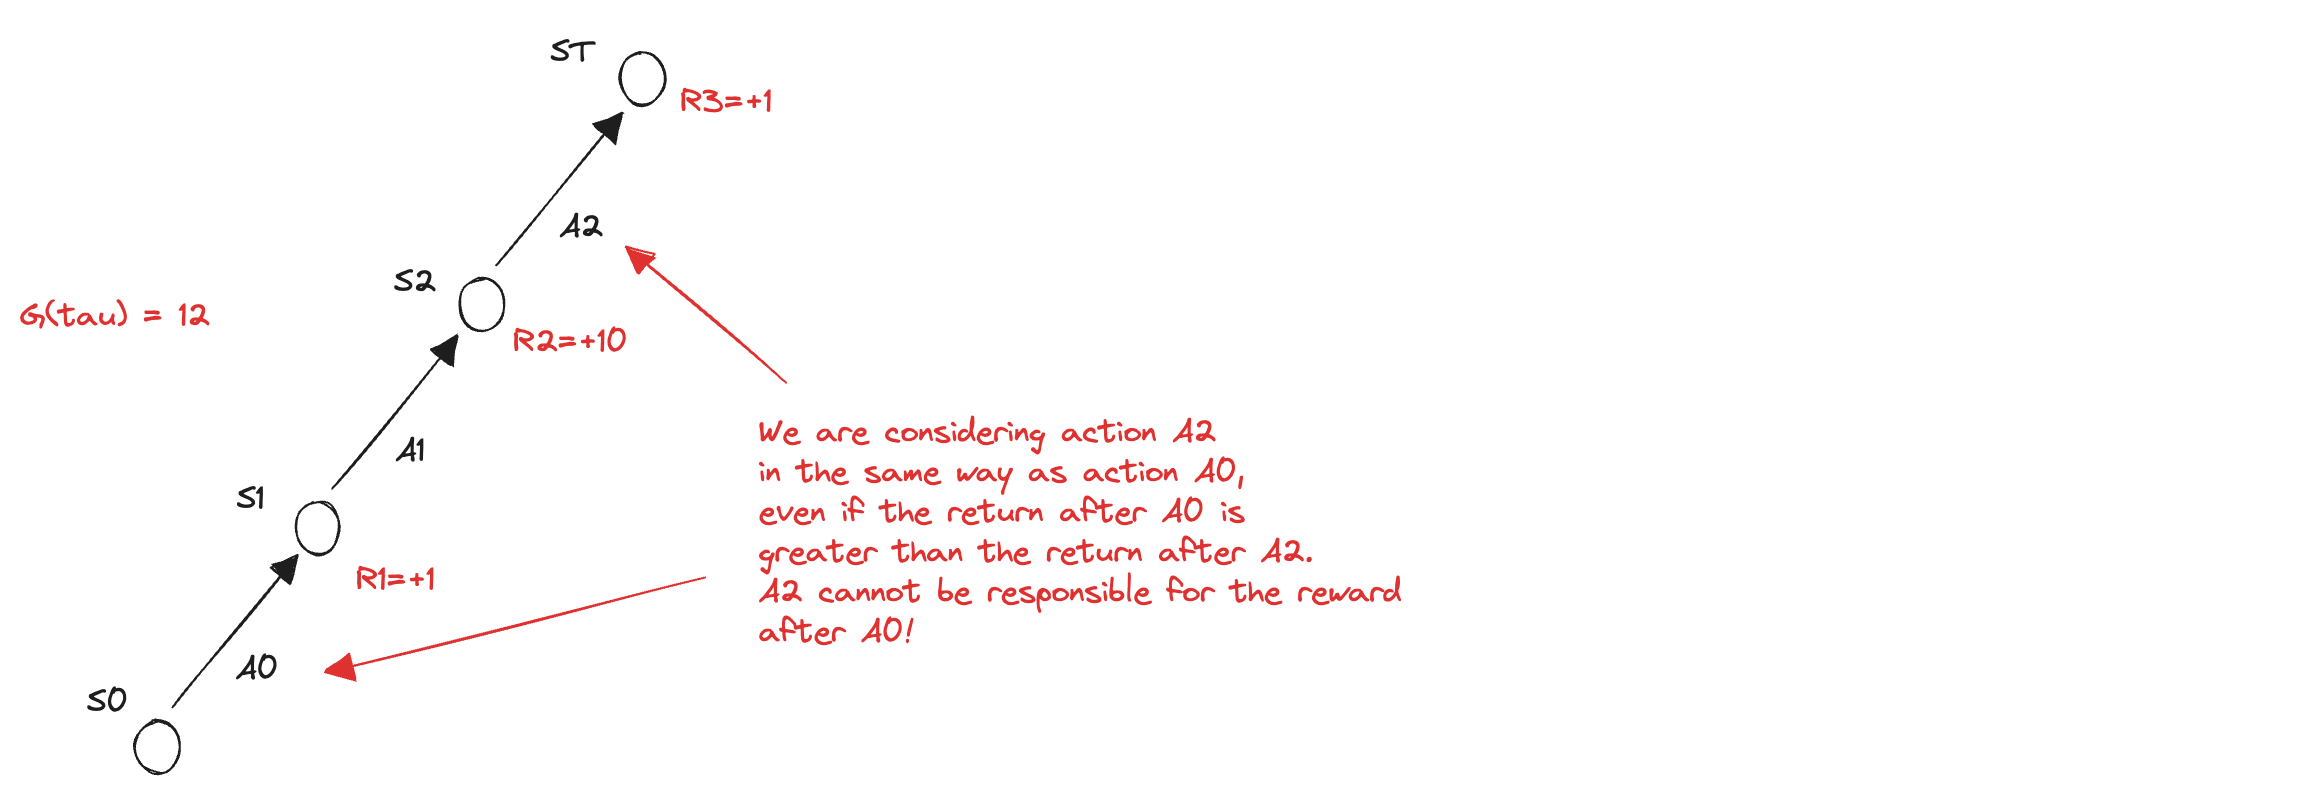

For each step in the trajectory, we calculate the return just from that step and use this value as the score to weight the log probability of the action taken at that time step:

$\displaystyle \nabla_\theta J(\theta) = \frac{1}{m}\sum\limits_{i=1}^{m}{ \sum\limits_{t=0}^{T-1}{\nabla_\theta \log \pi_\theta(a_t^{(i)}|s_t^{(i)})} G_t(\tau^{(i)})} $

## REINFORCE algorithm

The REINFORCE algorith ([R.J. Williams, **"Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning"**, Machine Learning (1992)](./papers/1992%20-%20Simple%20Statistical%20Gradient-Following%20Algorithms%20for%20Connectionist%20Reinforcement%20Learning.pdf)) was one of the first attempts to implements the idea of estimating the gradient using the full return and using a neural network to represent the policy. As in the previous chapter, we use the CartPole environment as an example:

In [23]:
import gymnasium

env = gymnasium.make('CartPole-v1', render_mode="rgb_array");

state_size = env.observation_space.shape;
action_size = env.action_space.n;

print('State Space: ', state_size);
print('Action Space: ', action_size);

State Space:  (4,)
Action Space:  2


First of all, we implement the parametric policy as a neural network, that takes the state as input and outputs a probability distribution over the actions:

In [24]:
import torch

def create_network(first_hidden_layer, second_hidden_layer):

      # Define a deep neural network using Sequential:
      # Each layer feeds directly into the next one.
      dnn = torch.nn.Sequential( 
            # First fully connected layer maps state inputs to 512 hidden units
            torch.nn.Linear(state_size[0], first_hidden_layer),
            
            # ReLU activation introduces nonlinearity
            torch.nn.ReLU(),
            
            # Second fully connected layer (hidden layer with 128 units)
            torch.nn.Linear(first_hidden_layer, second_hidden_layer),
            
            # Another ReLU activation
            torch.nn.ReLU(),
            
            # Output layer: one unit per possible action
            # Produces raw scores (logits) for each action
            torch.nn.Linear(second_hidden_layer, action_size)
      )
    
      # Return the constructed model
      return dnn;

In [25]:
first_hidden_layer= 512;
second_hidden_layer= 128;
pi = create_network(first_hidden_layer, second_hidden_layer);

The network will be trained, so we need an optimizer:

In [26]:
learning_rate = 0.001;
optimizer = torch.optim.RMSprop(pi.parameters(), lr=learning_rate);

To optimize the policy, we define the loss function corresponding to the negative of the performance measure, since most optimization algorithms are designed to perform gradient descent. The optimizer then updates the policy parameters by taking a gradient descent step according to this objective.

In [27]:
def optimize(rewards, logpas, discounts):
    
    # convert rewards and discounts to tensors
    rewards   = torch.as_tensor(rewards, dtype=torch.float32)
    discounts = torch.as_tensor(discounts, dtype=torch.float32)
    
    # number of time steps
    steps = rewards.shape[0]
    
    # compute causal returns:
    causal_return = torch.empty(steps, dtype=torch.float32)
    for step in range(steps):
        causal_return[step] = torch.sum(discounts[:steps - step] * rewards[step:])

    # stack log-probabilities
    logpas = torch.stack(logpas).squeeze(-1)

    # compute loss
    loss = -(causal_return * logpas).mean()

    # optimize the model
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In policy-based reinforcement learning, there is **no need to implement explicit exploration strategies**. The policy neural network itself produces a probability distribution over actions, which inherently defines both exploitation and exploration. We can write a function to compute the action preferences produced by the policy network and, depending on a greedy flag, either samples an action from the resulting probability distribution or selects the one with the highest likelihood. In both cases, we also return the log-probability of the chosen action, which is required for the update. This design unifies exploration and exploitation within a single function: sampling enables the agent to explore during training, while greedy selection allows for deterministic evaluation of the learned policy:

In [ ]:
def select_action(state, greedy=False):
    
    # convert state to tensor
    state = torch.as_tensor(state, dtype=torch.float32)

    # compute action preferences
    prefs = pi(state)

    # create a categorical distribution over actions
    dist = torch.distributions.Categorical(logits=prefs)

    # select the most probable action (greedy)
    if greedy:
        action = torch.argmax(prefs, dim=-1)
    # or sample an action (stochastic policy)
    else:
        action = dist.sample()

    # log-probability (used in REINFORCE loss)
    logpa = dist.log_prob(action)

    # return values
    return int(action.item()), logpa

We need a funciton to evaluate the performance of the agent, in this case we run several episodes selecting acions gre 

 and compute the average return

In [29]:
import numpy as np

def evaluate(episodes=5):

    # collect total rewards per episode
    rewards = [];

    # loop over episodes
    for episode in range(episodes):

        # reset the environment
        state, _ = env.reset();
        done = False;
        total_reward = 0.0;

        # run an episode
        while not done:
            action, _ = select_action(state, greedy=True);
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward;
            done = terminated or truncated;
    
        # store the total reward    
        rewards.append(total_reward);
    
    # return the average reward over the episodes
    return float(np.mean(rewards))

Finally, we can write the complete algorithm, where we collect a full trajectory and then perform an optimization step:

In [30]:
def reinforce(gamma, max_episodes):
 
    # calculate the discounts to be used in the episodes
    max_steps = 1000;
    discounts = gamma ** np.arange(max_steps)

    # create a score tracker for statistic purposes
    scores = []; 
    
    # train until for the maximum number of episodes
    for episode in range(max_episodes):
        
        # reset the environment at the beginning of the episode
        state, _ = env.reset()
        done = False;

        # log the rewards and the log of action probabilities
        logpas = []
        rewards = []
        
        # interact with the environment until the episode is done
        while not done:
            
            # select the action using the policy            
            action, logpa = select_action(state);

            # collect an experience tuple as usual 
            next_state, reward, terminal, truncated, _ = env.step(action);
            done = terminal or truncated

            # save the log probability and the reward
            logpas.append(logpa)
            rewards.append(reward)
            
            # update current state to next state
            state = next_state;
        
        # At the end of the episode, run one optimization step
        optimize(rewards, logpas, discounts);

        # Evaluate the policy
        score = evaluate(episodes=10);

        # store the score in the tracker
        scores.append(score);

        # print some informative logging 
        message = 'Episode {:03}, score {:05.1f}';
        message = message.format(episode+1, score);
        print(message, end='\r', flush=True);
    
    return scores

We can write an experiment to evaluate the REINFORCE algorithm in the cart-pole environment so that we can easily compare it and the value-based methods:

In [31]:
import joblib
import random

def experiment(gamma, 
               learning_rate, 
               first_hidden_layer, 
               second_hidden_layer, 
               max_episodes):
    
    global pi, optimizer;

    # List of random seeds to test algorithm stability
    seeds = (12, 34, 56, 78, 90);

    # Container to collect all experiment results
    results = [];

    # Run an independent training experiment per seed
    for seed in seeds:
    
        print("Experiment seed: ", seed);
            
        # Set all relevant random seeds for reproducibility
        torch.manual_seed(seed);
        np.random.seed(seed);
        random.seed(seed);

        # reset the environment
        env.reset(seed=seed);
        env.action_space.seed(seed)
        env.observation_space.seed(seed)

        # create a new model
        pi = create_network(first_hidden_layer, second_hidden_layer);
        optimizer = torch.optim.RMSprop(pi.parameters(), lr=learning_rate);

        # train the network
        scores = reinforce(gamma, max_episodes);
            
        # smooth the result using a sliding window
        sliding_windows = 25;
        scores = np.convolve(scores, np.ones(sliding_windows)/sliding_windows, mode='valid');
            
        # collect the results
        results.append(scores);

        print("");

    max_score = np.max(results, axis=0).T;
    min_score = np.min(results, axis=0).T;
    mean_score = np.mean(results, axis=0).T;

    experiment_results = {
        'max_score': max_score,
        'min_score': min_score,
        'mean_score': mean_score
    }

    # Save results
    joblib.dump(experiment_results, '../models/reinforce_results.joblib');

    return experiment_results;

We now define a specific set of hyperparameters controlling both the training process and the neural network architecture, and we execute a single training experiment to observe how the agent’s performance evolves over time under these conditions:

In [32]:
# Define the experiment setup and hyperparameters
gamma = 0.99;              # discount factor
learning_rate = 0.001;     # step size for the optimizer
first_hidden_layer = 64;   # size of the first hidden layer
second_hidden_layer = 32;  # size of the second hidden layer

# Number of training episodes per experiment
max_episodes = 1500;

# run the experiment
reinforce_results = experiment(gamma, learning_rate, first_hidden_layer, second_hidden_layer, max_episodes);

Experiment seed:  12
Episode 1500, score 125.3
Experiment seed:  34
Episode 1500, score 156.3
Experiment seed:  56
Episode 1500, score 136.7
Experiment seed:  78
Episode 1500, score 439.9
Experiment seed:  90
Episode 1500, score 500.0


We can load the results of NFQ in order to compare the performances of the two algorithms:

In [33]:
nfq_results = joblib.load('../models/nfq_results.joblib');

As for value-based algorithms, we can plot the performance of the algorithm over episodes:   

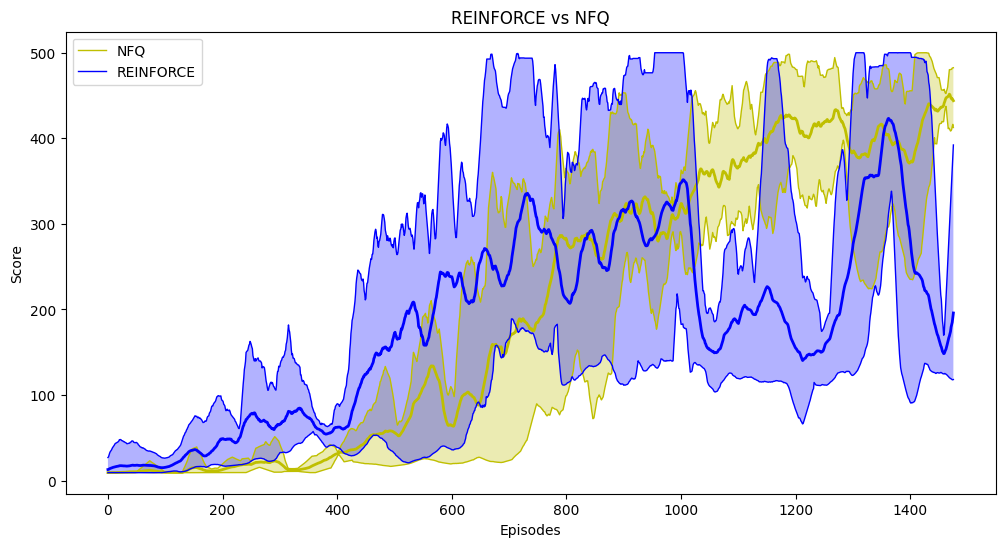

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6));
plt.title('REINFORCE vs NFQ');
plt.ylabel('Score');
plt.xlabel('Episodes');

nfq_episodes = range(len(nfq_results['max_score']));
reinforce_episodes = range(len(reinforce_results['max_score']));

plt.plot(nfq_results['max_score'], 'y', linewidth=1, label="NFQ");
plt.plot(nfq_results['min_score'], 'y', linewidth=1);
plt.plot(nfq_results['mean_score'], 'y', linewidth=2);
plt.fill_between(nfq_episodes, nfq_results['min_score'], nfq_results['max_score'], facecolor='y', alpha=0.3);

plt.plot(reinforce_results['max_score'], 'b', linewidth=1, label="REINFORCE");
plt.plot(reinforce_results['min_score'], 'b', linewidth=1);
plt.plot(reinforce_results['mean_score'], 'b', linewidth=2);
plt.fill_between(reinforce_episodes, reinforce_results['min_score'], reinforce_results['max_score'], facecolor='b', alpha=0.3);

plt.legend()
plt.show();

The REINFORCE algorithm performs **well on simple problems** and, in theory, it converges to a local optimum under suitable conditions. However, because it relies entirely on Monte Carlo estimates of the return to compute its gradient, the resulting updates **suffer from high variance**. Every random factor (the initial state, the stochastic transitions of the environment, and the randomness of the policy itselfù9 accumulates along the trajectory. As a result, the return becomes a very noisy training signal, making learning unstable and inefficient. In practice, this means that REINFORCE, while elegant and conceptually important, is too sample-inefficient to be used on complex tasks.
Nevertheless, it remains a valuable reference algorithm: it is simple, lightweight, and easy to implement.

## Vanilla Policy Gradient (VPG)

The core idea behind policy gradient methods is simple: **increase the probability of actions that lead to higher returns** and **decrease the probability of those that lead to lower returns**, gradually improving the policy toward the optimal one. However, since we estimate returns using noisy Monte Carlo samples, the resulting gradient estimates often have **high variance**, which can slow down learning. For example, in an environment like Cart-Pole, where all rewards are positive, it’s difficult to tell which actions are merely good and which are truly the best, requiring a large amount of data to make that distinction reliably.

It would be helpful if we had a way to **distinguish between actions taken in the same state**. To achieve this, we can use the **advantage function**, which measures how much better (or worse) an action is compared to the average action in that state.

$\displaystyle a_\pi(s,a) = q_\pi(s,a) - v_\pi(s) $

In practice, we can express the advantage at time step $t$ approximately as

$\displaystyle A(S_t,A_t) = R_t + \gamma R_{t+1} + ... + \gamma^{T-1} R_T - v_\pi(S_t) $

An estimate of it is the return minus the estimated expected return from that state:

$\displaystyle A(S_t,A_t) = G_t - V(S_t) $

Using the advantage somewhat **centers scores around zero**: better-than-average actions have a positive score (increasing probabilities), worse-than-average have a negative score (decreasing probabilities). However, we need **two neural networks**, one for learning the policy and one for learning the state-value function in order to estimate the advantage: 

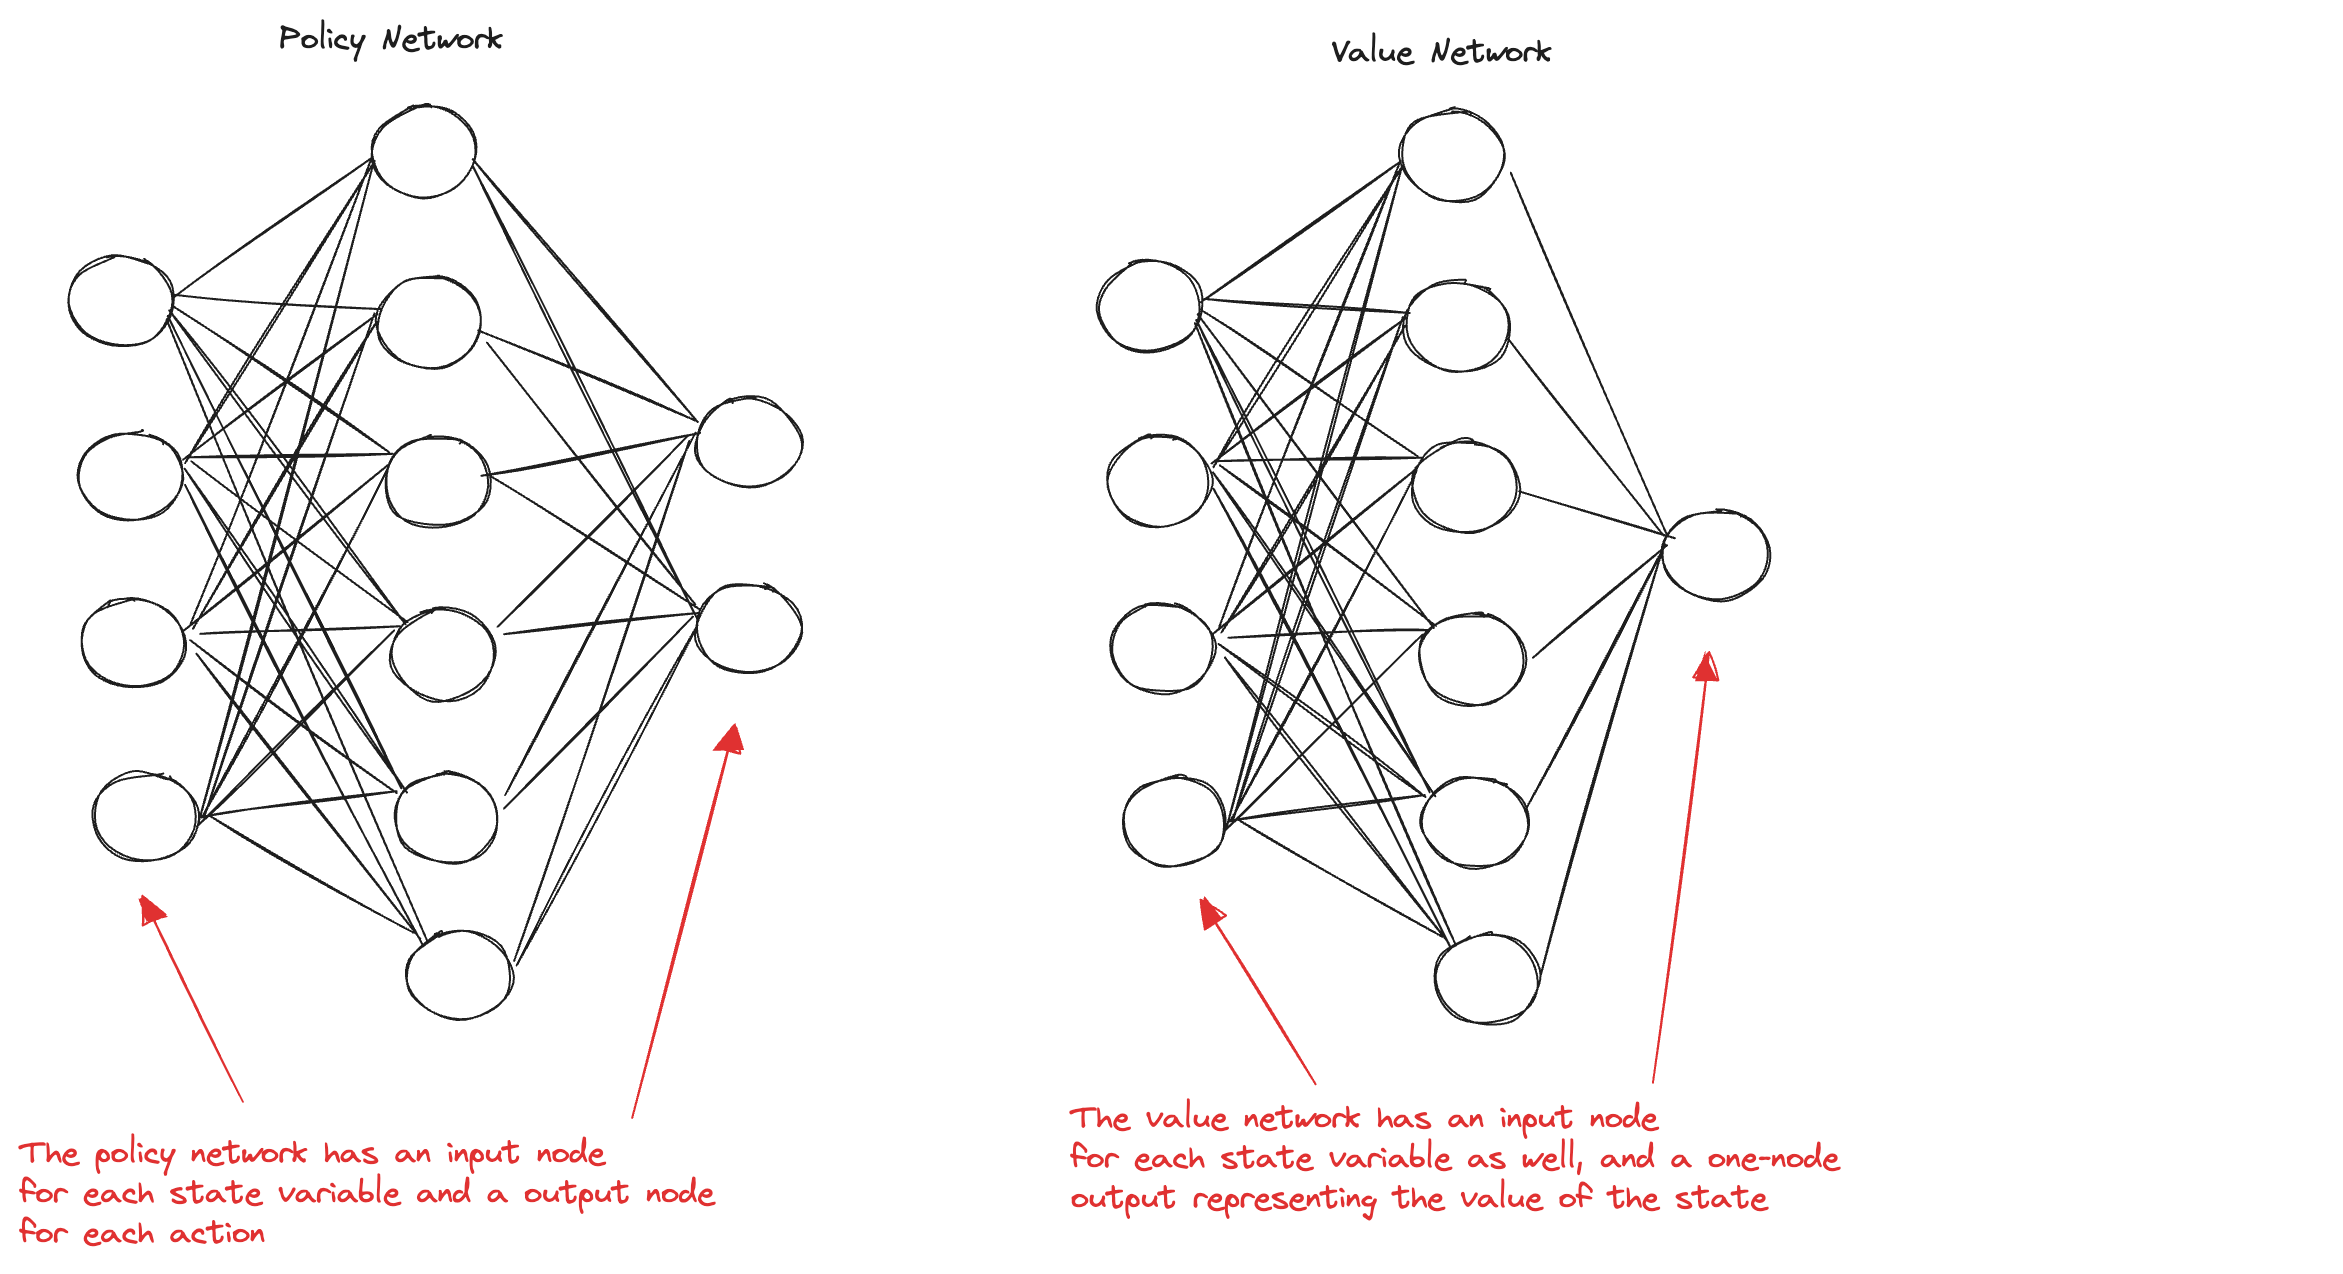

The perforcance measure for the value function is simple, the mean squared Monte Carlo error:

$\displaystyle J_v(\phi)=-\frac{1}{m}\sum\limits_{i=0}^{m}{\left[\left(G_t(\tau^{(i)}) - V(s_t^{(i)})\right)^2\right]} $

For the policy network, we can update the performance measure and its gradient using the advantage instead of the return:

$\displaystyle J_{\pi}(\theta) = E_{\tau \sim \pi_\theta } \left[ G(\tau) \right] = \sum\limits_{\tau} p(\tau|\pi_\theta) (G_t(\tau) - V(s_t)$

$\displaystyle \nabla_\theta J_{\pi}(\theta) = \frac{1}{m}\sum\limits_{i=1}^{m}{ \sum\limits_{t=0}^{T-1}{\nabla_\theta \log \pi_\theta(a_t^{(i)}|s_t^{(i)})} (G_t(\tau^{(i)})} - V(s_t^{(i)})) $

It is essential to add another improvement. We want our policy to exploit what it has already learned, but also to explore other possibilities (to avoid premature convergence to suboptimal actions). However, during training, the policy’s probability distribution often collapses too early onto a single action (especially when early rewards are noisy or misleading). This makes the agent **overconfident** and prevents it from exploring alternative, possibly better, behaviors. We can use a measures of uncertainty or randomness of the distribution, like the entropy:



is to add an **entropy term** to to the loss function. We can interpret entropy in many different ways, from the amount of information we can gain by sampling from a distribution, to the number of ways we can order a set. In this context, we can think of entropy in a straightforward way. A uniform distribution, which has evenly distributed samples, has high entropy. If we have two samples, both with a 50% chance, then the entropy is the highest it can be for a two-sample set, conversely, if we have two samples, one with 100% chance, then the entropy is the lowest. The way to use entropy in policy-gradient methods is to add the weighted entropy to the performance function **to encourage having evenly distributed actions**. That way, a policy (with evenly distributed actions) yields the highest entropy and contributes to maximize the performance. On the other hand, converging on a single action (which means entropy is zero) doesn’t increase the performance measure.

$\displaystyle \nabla_\theta J(\theta) = \frac{1}{m}\sum\limits_{i=1}^{m}{ \sum\limits_{t=0}^{T-1}{\nabla_\theta [ \log \pi_\theta(a_t^{(i)}|s_t^{(i)})} (G_t(\tau^{(i)})} - V(s_t^{(i)};\phi)) + \beta H(s_t^{(i)};\theta) ]$

This algorithm is called **Vanilla policy gradient**. To implement it, we need a secondo funciton to create the state-value new neural network that has a single output:

In [ ]:
import torch

def create_value_network(first_hidden_layer, second_hidden_layer):

      # Define a deep neural network using Sequential:
      # Each layer feeds directly into the next one.
      dnn = torch.nn.Sequential( 
            # First fully connected layer maps state inputs to 512 hidden units
            torch.nn.Linear(state_size[0], first_hidden_layer),
            
            # ReLU activation introduces nonlinearity
            torch.nn.ReLU(),
            
            # Second fully connected layer (hidden layer with 128 units)
            torch.nn.Linear(first_hidden_layer, second_hidden_layer),
            
            # Another ReLU activation
            torch.nn.ReLU(),
            
            # Output layer: xxx
            torch.nn.Linear(second_hidden_layer, 1)
      )
    
      # Return the constructed model
      return dnn;

In [ ]:
first_hidden_layer= 512;
second_hidden_layer= 128;
v = create_value_network(first_hidden_layer, second_hidden_layer);

We need also to the select_action method of the first network (the policy network) in order to calculate also the entropy term:

In [ ]:
def select_action(state, greedy=False):

    # convert state to tensor
    state = torch.as_tensor(state, dtype=torch.float32)

    # compute action preferences
    prefs = pi(state)

    # create a categorical distribution over actions
    dist = torch.distributions.Categorical(logits=prefs)

    # select the most probable action (greedy)
    if greedy:
        action = torch.argmax(prefs, dim=-1)
    # or sample an action (stochastic policy)
    else:
        action = dist.sample()

    # log-probability (used in REINFORCE loss)
    logpa = dist.log_prob(action)

    # calculate the entropy
    entropy = dist.entropy()

    # return values
    return int(action.item()), logpa, entropy

The optimize method is different from the previous one, because we have two neural networks to optimize:  

In [ ]:
def optimize(rewards, logpas, entropies, discounts):
    
    # get the length of the episode
    T = len(rewards)
    
    # calculate the sum of discounted returns for all steps
    returns = np.array([np.sum(discounts[:T-t] * rewards[t:]) for t in range(T)])

    # format the variables as a tensor
    returns = torch.FloatTensor(returns)
    
    # prepare the log probabilities, the entropies and the values
    logpas = torch.cat(logpas)
    entropies = torch.cat(entropies) 
    values = torch.cat(values)
    
    # estimate the advantages
    advantage = returns - values

    # calculate the policy loss
    beta = 0.001
    policy_loss = -(advantage.detach() * logpas + beta * entropies).sum()

    # calculate the value loss
    value_loss = advantage.pow(2).sum()
        
    # optimize the policy network
    policy_optimizer.zero_grad()
    policy_loss.backward()
    policy_optimizer.step()

    # optimize the value network
    value_optimizer.zero_grad()
    value_loss.backward()
    value_optimizer.step()

Finally, we can write the complete algorithm, similar to REINFORCE, but with the addition of the value network and the entropy term:

In [24]:
def vpg(env_name, seed, parameters):

    # unpack the parameters
    gamma = parameters['gamma']
    learning_rate = parameters['learning_rate']
    max_time = parameters['max_time']
    max_episodes = parameters['max_episodes']
    max_score = parameters['max_score']
    episodes_window = parameters['episodes_window']

    # create the environment
    env = gymnasium.make(env_name)

    # access the state and action sizes of the environment 
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    # calculate the discounts to be used in the episodes
    max_steps = 1000
    discounts = np.logspace(start=0, stop=max_steps , num=max_steps, base=gamma)

    # set the seeds for reproducibility of results
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    env.np_random = np.random.Generator(np.random.PCG64(seed))

    # create the policy model and its optimizer
    policy_model = PolicyApproximator(state_size, action_size)
    policy_optimizer = torch.optim.RMSprop(policy_model.parameters(), lr=learning_rate)

    # create the value model and its optimizer
    value_model = ValueApproximator(state_size)
    value_optimizer = torch.optim.RMSprop(value_model.parameters(), lr=learning_rate)

    # episode stats trackers 
    episode_steps = []
    episode_return = []
    episode_seconds = []
    episode_scores = [] 

    # total stats trackers
    total_step = 0
    training_time = 0
    results = np.empty((max_episodes+1, 4))
    results[:] = np.nan
        
    # train until we reach a terminal condition
    for episode in count():

        # get the start time of the episode
        episode_start = time.time()
        
        # set return to 0
        discounted_return = 0
        
        # reset the environment before starting the episode
        state = env.reset()[0]
        
        # log the rewards, the log of action probabilities, entropies and values
        logpas = []
        rewards = []
        entropies = []
        values = []
        
        # interact with the environment until the episode is done
        for step in count():
    
            # select the action using the policy
            action, logpa, entropy = policy_model.select_action(state)

            # collect an experience tuple as usual 
            next_state, reward, is_terminal, is_truncated, info = env.step(action)
            is_done = is_terminal or is_truncated
            is_failure = is_terminal and not is_truncated

            # calculate the value using the value network
            value = value_model(state)

            # save the log probability, entropy, reward and value
            logpas.append(logpa)
            entropies.append(entropy)
            rewards.append(reward)
            values.append(value)

            # update current state to next state
            state = next_state
        
            # update the return
            discounted_return += reward
            
            if is_done:
                gc.collect() 
                break

        # then, run one optimization step
        optimize(policy_model, value_model, rewards, logpas, values, entropies, policy_optimizer, value_optimizer, discounts)

        # evaluate the learned policy after the episode
        score = evaluate(policy_model, env)

        # timing stuff
        episode_elapsed = time.time() - episode_start

        # update episode stats
        episode_steps.append(step)
        episode_return.append(discounted_return)
        episode_seconds.append(episode_elapsed)
        episode_scores.append(score)

        # update total stats
        total_step += step
        training_time += episode_elapsed  

        # average stats over some recent episodes
        mean_return = np.mean(episode_return[-episodes_window:])
        mean_score = np.mean(episode_scores[-episodes_window:])

        # report results
        results[episode] = total_step, mean_return, mean_score, training_time

        # informative print logging  
        message = 'episode {:04}, steps {:06}, average score {:05.1f}'
        message = message.format(episode, total_step, mean_score)
        print(message, end='\r', flush=True)

        # check max episodes achievement criteria
        if (episode >= max_episodes):
            print(message, ' --> reached_max_episodes ')
            break

        # check max time achievement criteria
        if (training_time >= max_time):
            print(message, ' --> reached_max_time ')
            break

        # check max score achievement criteria
        if (mean_score >= max_score):
            print(message, ' --> reached_max_score ')
            break
    
    return policy_model, score, results

We can try the algorithm in the cartpole environment:

In [25]:
vpg_results, vpg_agent, vpg_score = run_experiment(name = 'vpg_results', algorithm = vpg) 

TypeError: 'NoneType' object is not subscriptable

We can compare VPG with REINFORCE, Notice how VPG is more sample efficient, instead REINFORCE is too inefficient to be a practical algorithm.

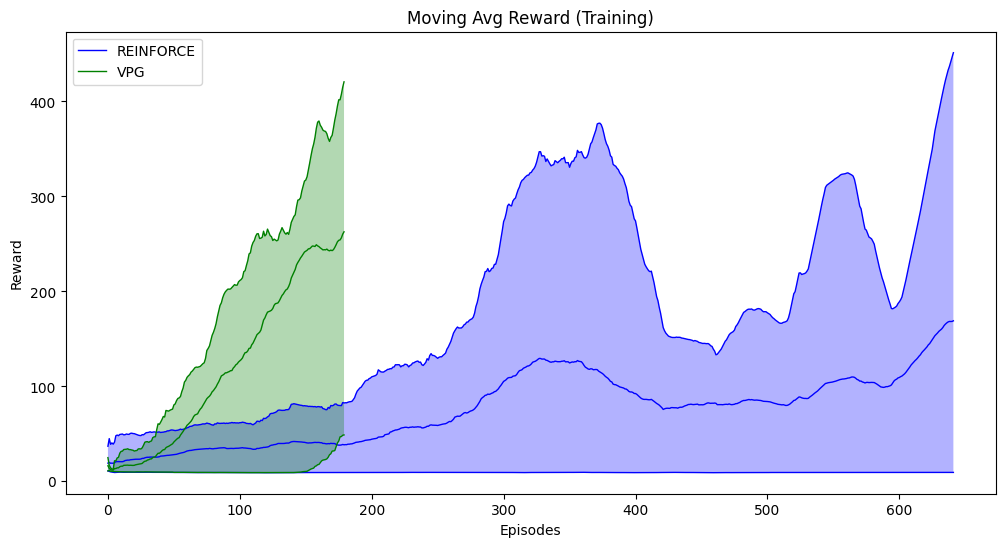

In [ ]:
show_result('avg_training_reward','REINFORCE', reinforce_results, 'VPG', vpg_results) 

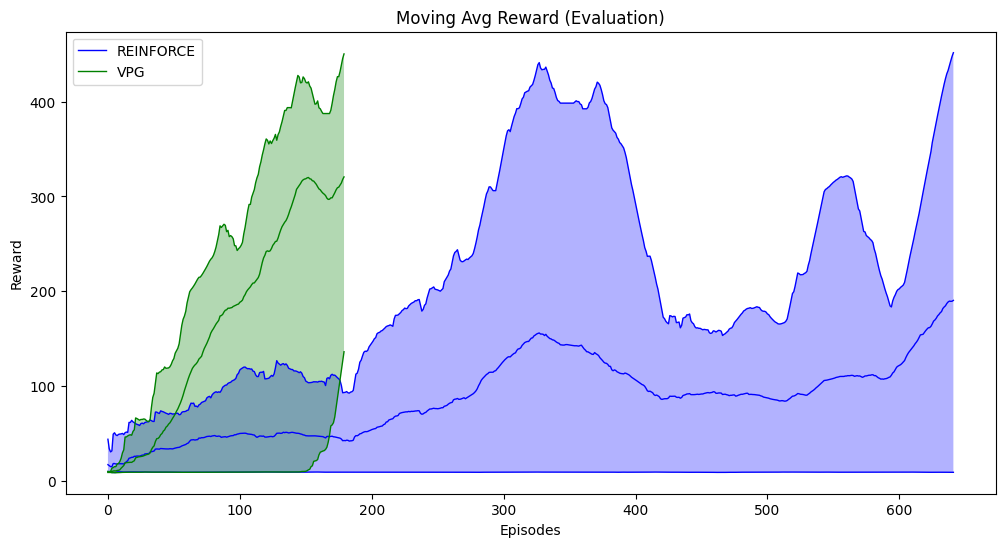

In [ ]:
show_result('avg_evaluation_reward','REINFORCE', reinforce_results, 'VPG', vpg_results) 

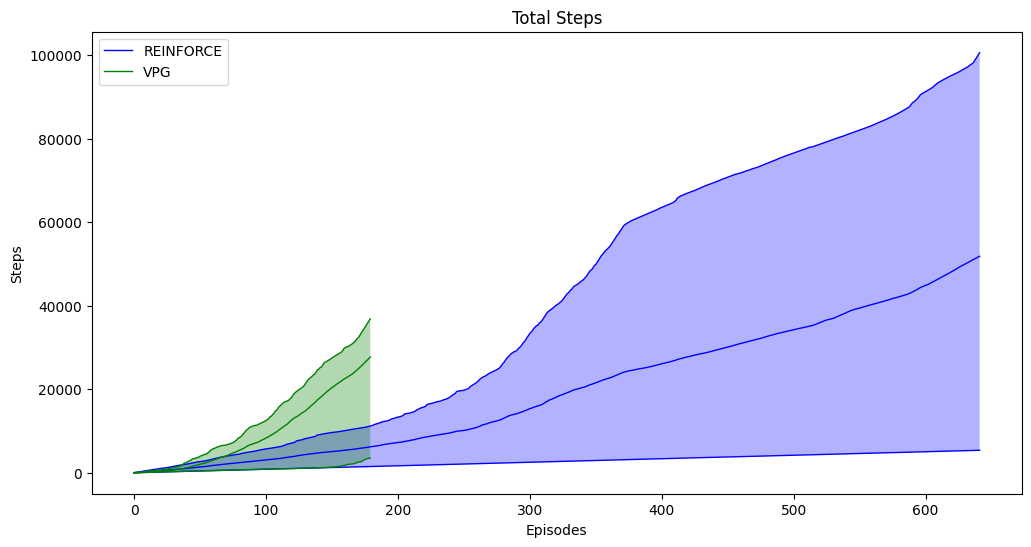

In [ ]:
show_result('total_steps','REINFORCE', reinforce_results, 'VPG', vpg_results) 

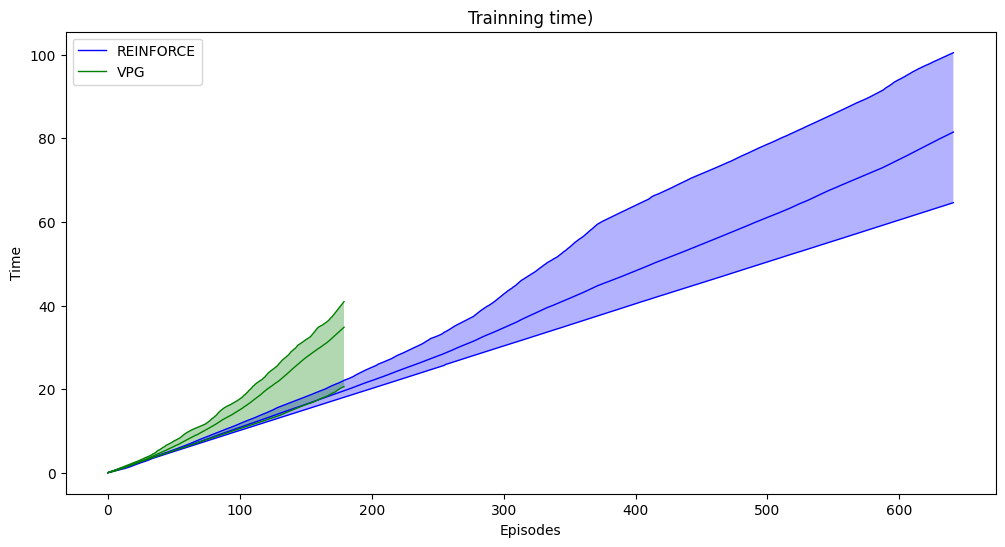

In [ ]:
show_result('training_time','REINFORCE', reinforce_results, 'VPG', vpg_results) 

VPG is a pretty robust method for simple problems; it is, for the most part, unbiased because it uses an unbiased target for learning both the policy and value function. That is, it uses Monte Carlo returns, which are complete actual returns experienced directly in the environment, without any bootstrapping. The only bias in the entire algorithm is because we use function approximation, which is inherently biased.

## Asynchronous Advantage Actor-Critic (A3C)

One of the main sources of variance in DRL algorithms is how **correlated and non-stationary** online samples are. In value-based methods, we use a replay buffer to uniformly sample mini-batches of (for the most part) independent and identically distributed data. Unfortunately, this is limited to off-policy methods, because on-policy agents cannot reuse data generated by previous policies. In on-policy methods (likes the policy-based methods), instead of using the replay buffer, we can have **multiple workers generating experience** on **multiple instances of the environment** in parallel and asynchronously updating the policy and value function. This can help to de-correlate the data used for training and to reduce the variance of the algorithm.

![](./images/multiple-workers.png)

The **Asynchronous Advantage Actor-Critic (A3C)** algorithm ([Vlad Mnih et al. **"Asynchronous Methods for Deep Reinforcement Learning"**, ICML 2016)](./papers/2016%20-%20Asynchronous%20Methods%20for%20Deep%20Reinforcement%20Learning.pdf) uses concurrent actors to generate a broad set of experience samples in parallel.  Moreover, it also uses **n-step returns with bootstrapping** to learn the policy and value function.




This behavior can be implemented using **multiple threads**, one for each worker, however Python threads cannot take advantage of CPU with multiple cores, due to  internal implementation details. The workaround is to use **multiple processes** using the multiprocessing module. Unfortunately, the multiprocessing library has problems in running in an iterative environment like Jupyter, so we will use the threading library. We need to create a work function that will be executed by each thread. In the following example, the work function just waits for a random time before printing its rank: 

In [ ]:
import time

def work(rank, sleep_time):
    time.sleep(sleep_time)
    print(rank) 

Then we create a pool of threads, execute them in parallel and finally wait for the threads to finish:

In [ ]:
import random

from threading import Thread

def main():
    # number of workers
    n_workers = 4

    print('start')
    if __name__ == '__main__':
        
        workers = [Thread(target=work, args=(rank, random.uniform(1, 3),)) for rank in range(n_workers)]  

        # start workers
        [w.start() for w in workers]

        # wait for all workers to finish
        [w.join() for w in workers]

    print('end')

main()

start
1
0
3
2
end


As you can see, workers are running in parallel: since they wait for a different amount of time, the order of the output is not deterministic. However, we can see that the rank of the thread is always the same, because the pool of threads is created with a fixed number of workers. Moreover, the "end" string is always printed at the end, because the main thread waits for the completion of all the workers.

Moreover, when writing concurrent programs we may need to share data or resources between threads. Since threads live in the same memory space, they have access to the same (public) data. Thus, we can for example simply use a global variable to which all threads have read and write access. Moreover,  typically we need be protect with a mutual exclusion lock some shared variables in order to prevent race conditions. Python provides a mutual exclusion lock for use with processes via the Lock class. In this example, we create a shared counter and we use a lock to synchronize access to it:

In [ ]:
def work(rank, iterations, lock):

    # all threads can access this shared variable
    global counter

    for _ in range(iterations):

        time.sleep(random.uniform(1, 10)/100)

        # lock the shared variable
        lock.acquire()

        counter += 1
        print(counter, " - int's me ", rank)

        # unlock the shared variable
        lock.release()

In [ ]:
from threading import Lock

# number of workers
n_workers = 4

print('start')

# number of iterations per worker
iterations = 5

# shared variable
counter = 0

# create a lock
lock = Lock()
    
# create workers
workers = [Thread(target=work, args=(rank, iterations, lock)) for rank in range(n_workers)]  

# start workers
[w.start() for w in workers]

# wait for all workers to finish
[w.join() for w in workers]

print ('end')

start


1  - int's me  1
2  - int's me  2
3  - int's me  0
4  - int's me  3
5  - int's me  2
6  - int's me  0
7  - int's me  3
8  - int's me  0
9  - int's me  1
10  - int's me  2
11  - int's me  3
12  - int's me  0
13  - int's me  2
14  - int's me  1
15  - int's me  0
16  - int's me  1
17  - int's me  3
18  - int's me  3
19  - int's me  2
20  - int's me  1
end


We can write the work function used by each agent in the A3C algorithm. The agent interacts with the environment ad update the global networks parameters:

In [ ]:
# create a global object to share information between the workers
shared_info = {}

In [ ]:
def agent_work(rank, lock):
    
    # access the global shared variables
    global shared_info

    # create a different seed for each worker, since we need different
    # experiences from each one of them
    local_seed = shared_info['seed'] + rank
    
    # create the local environment
    env = gymnasium.make(shared_info['env_name'])

    # create a uniquely seeded environment for each worker
    env.np_random = np.random.Generator(np.random.PCG64(local_seed))
    
    # access the state and action sizes of the environment 
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n
    
    # create the local policy model 
    # initialize weights with the weights of the shared policy model
    local_policy_model = PolicyApproximator(state_size, action_size)
    local_policy_model.load_state_dict(shared_info['shared_policy_model'].state_dict())
    
    # do the same thing with the value model
    local_value_model = ValueApproximator(state_size)
    local_value_model.load_state_dict(shared_info['shared_value_model'].state_dict())

    # increment the global episodes counter
    with lock:
        shared_info['episode'] = shared_info['episode'] + 1
        local_episode = shared_info['episode']

    # start the training loop, until the worker is signaled to get out of it
    # we reach a terminal condition
    while not shared_info['out_signal']: 

        # get the start time of the episode
        episode_start = time.time()

        # set return to 0
        discounted_return = 0
        
        # reset the environment before starting the episode
        state = env.reset()[0]
        
        # log the rewards, the log of action probabilities, entropies and values
        logpas = []
        rewards = []
        entropies = []
        values = []

        n_steps_start = 0

        # interact with the environment
        for step in count():
            
            # select the action using the local policy
            action, logpa, entropy = local_policy_model.select_action(state)

            # collect an experience tuple as usual 
            next_state, reward, is_terminal, is_truncated, info = env.step(action)
            is_done = is_terminal or is_truncated
            is_failure = is_terminal and not is_truncated

            # calculate the value using the value network    
            value = local_value_model(state)

            # save the log probability, entropy, reward and value
            logpas.append(logpa)
            entropies.append(entropy)
            rewards.append(reward)
            values.append(value)

            # update current state to next state
            state = next_state
        
            # update the return
            discounted_return += reward
                                    
            # if we collected enough steps or if the episode is done
            # calculate the n-step return and optimize the model
            if is_done or step - n_steps_start == shared_info['max_n_steps']:
                
                # if it’s a failure, then the value of the next state is 0; otherwise, we bootstrap
                next_value = 0 if is_failure else value.detach().item()
                rewards.append(next_value)
                
                # optimize the model
                optimize(logpas, entropies, rewards, values, 
                         local_policy_model, local_value_model,
                         shared_info['shared_policy_model'], 
                         shared_info['shared_value_model'],
                         shared_info['shared_policy_optimizer'], 
                         shared_info['shared_value_optimizer'],
                         shared_info['discounts'])
                
                # load the shared updated models parameters into the local models
                local_policy_model.load_state_dict(shared_info['shared_policy_model'].state_dict())
                local_value_model.load_state_dict(shared_info['shared_value_model'].state_dict())
                
                logpas = []
                entropies = [] 
                rewards = []
                values = []

                n_steps_start = step

            if is_done:
                break

        # evaluate the local policy after the episode
        score = evaluate(local_policy_model, env)

        # update total stats
        episode_elapsed = time.time() - episode_start
        with lock:
            shared_info['total_steps'] += step
            shared_info['training_time'] += episode_elapsed / shared_info['n_workers']

        # update global episode stats
        with lock:
            shared_info['episode_steps'].append(step)
            shared_info['episode_return'].append(discounted_return)
            shared_info['episode_seconds'].append(episode_elapsed)
            shared_info['episode_scores'].append(score)  
        
        # average stats over some recent episodes
        episodes_window = shared_info['episodes_window']
        mean_return = np.mean(shared_info['episode_return'][-episodes_window:])
        mean_score = np.mean(shared_info['episode_scores'][-episodes_window:])

        # report results
        shared_info['results'][local_episode] = step, mean_return, mean_score, episode_elapsed / shared_info['n_workers']

        # informative print logging  
        message = 'worker {:02} - episode {:04}, steps {:06}, average score {:05.1f}'
        message = message.format(rank, local_episode, shared_info['total_steps'], mean_score)
        with lock:
            print(message, end='\r', flush=True)

        # check if we should stop
        if shared_info['out_signal'] == 1:
            break

        # check max episodes achievement criteria   
        if (local_episode >= shared_info['max_episodes']):
            print(message, ' --> reached_max_episodes ')
            shared_info['out_signal'] = 1
            break

        # check max time achievement criteria
        if (shared_info['training_time'] >= shared_info['max_time']):
            print(message, ' --> reached_max_time ')
            shared_info['out_signal'] = 1
            break

        # check max score achievement criteria
        if (mean_score >= shared_info['max_score']):
            print(message, ' --> reached_max_score ')
            shared_info['out_signal'] = 1
            break
            
        # else go work on another episode by
        # getting a new episode id from the
        # global protected counter
        with lock:
            shared_info['episode'] = shared_info['episode'] + 1
            local_episode = shared_info['episode']

    env.close() 
    del env

Workers append the value of the next state, whether terminal or not, to the reward sequence before calling the optimize function (in VPG we were using the full returns for the advantage estimate). In that way, the reward variable contains all rewards from the partial trajectory and the state-value estimate of that last state. We can see this as having the partial return (the sequence of rewards) and the **predicted remaining return** in the same place. You can realize that this is an **n-step return**: the agent go out for n-steps collecting rewards, and then **bootstrap** after that n-th state (or before if he lands on a terminal state that comes first):

$\displaystyle A(S_t,A_t) = R_t + \gamma R_{t+1} + ... \gamma^n R_{t+n} + \gamma^{n+1} V(S_{t+n+1}) - V(S_t) = G_{t:t+n} - V(S_{t+n+1}) $

Notice the bootstrapping, this is what makes this algorithm an **actor-critic method**. Now, We can use that n-step return to improve the value function estimate: 

$\displaystyle L_v(\phi)=\frac{1}{m}\sum\limits_{i=0}^{{m}}{\left[\left(G_{t:t+n}^{(i)} - V(s_{t+n+1}^{(i)};\phi)\right)^2\right]} $

We also use this n-step advantage estimate for updating the policy networks:

$\displaystyle \nabla_\theta J(\theta) = \frac{1}{m}\sum\limits_{i=1}^{m}{ \sum\limits_{t=0}^{n}{\nabla_\theta [ \log \pi_\theta(a_t^{(i)}|s_t^{(i)})} (G_{t:t+n}^{(i)}} - V(s_{t+n+1}^{(i)};\phi) + \beta H(s_{t+n+1}^{(i)};\theta) ]$

We can write the optimize model function, which similar to the one of VPG however this time we are optimizing the shared models: 

In [ ]:
def optimize(logpas, entropies, rewards, values, 
             local_policy_model, local_value_model, 
             shared_policy_model, shared_value_model,
             shared_policy_optimizer, shared_value_optimizer, 
             discounts):
    
    # get the length of the episode
    T = len(rewards)
    
    # calculate the sum of discounted returns for the n-step steps
    # remember: rewards includes the bootstrapping value
    returns = np.array([np.sum(discounts[:T-t] * rewards[t:]) for t in range(T)])
    
    # format the variables as a tensor
    returns = torch.FloatTensor(returns[:-1])

    # prepare the log probabilities, the entropies and the values
    logpas = torch.cat(logpas)
    entropies = torch.cat(entropies)
    values = torch.cat(values)

    # estimate the advantages
    advantage = returns - values
    
    # calculate the policy loss
    beta = 0.001
    policy_loss = -(advantage.detach() * logpas + beta * entropies).sum()

    # calculate the value loss
    value_loss = advantage.pow(2).sum()

    # optimize the policy network
    # notice, we now zero the shared policy optimizer
    shared_policy_optimizer.zero_grad()
    policy_loss.backward()

    # iterating over all local and shared policy network parameters
    # and copy every gradient from the local to the shared model
    for local_param, shared_param in zip(local_policy_model.parameters(), shared_policy_model.parameters()):
        if shared_param.grad is None:
            shared_param._grad = local_param.grad
    
    # once the gradients are copied into the shared optimizer, we run an optimization step
    shared_policy_optimizer.step()
    
    # optimize the value network
    shared_value_optimizer.zero_grad()
    value_loss.backward()
    
    # iterating over all local and shared value network parameters
    # and copy every gradient from the local to the shared model
    for local_param, shared_param in zip(local_value_model.parameters(), shared_value_model.parameters()):
        if shared_param.grad is None:
            shared_param._grad = local_param.grad
    
    # once the gradients are copied into the shared optimizer, we run an optimization step
    shared_value_optimizer.step()

One of the most critical aspects of A3C is that **its network updates are asynchronous and lockfree**. As we already discussed, having a shared model creates a need for a blocking mechanism to prevent workers from overwriting other updates, however this would be inefficient. Instead, A3C uses an update style called a **Hogwild!**, in which workers access to shared model with the possibility of overwriting each other's work, which is shown to achieve a near-optimal rate of convergence and outperforming alternative schemes that use locking by an order of magnitude: [F. Niu et al. **"HOGWILD!: A Lock-Free Approach to Parallelizing Stochastic Gradient Descent"**, NIPS 2011](./papers/2011%20-%20HOGWILD!-%20A%20Lock-Free%20Approach%20to%20Parallelizing%20Stochastic%20Gradient%20Descent.pdf).

We can write the A3C algorithm, which is similar to VPG, but with the addition of the n-step returns and the multiple workers:

In [ ]:
def a3c(env_name, seed, parameters):

    # unpack the parameters
    gamma = parameters['gamma']
    learning_rate = parameters['learning_rate']
    max_time = parameters['max_time']
    max_episodes = parameters['max_episodes']
    max_score = parameters['max_score']
    episodes_window = parameters['episodes_window']
    n_workers = parameters['n_workers']
    max_n_steps = parameters['max_n_steps']
    
    # access the global object
    global shared_info

    # define the seed for workers
    shared_info['seed'] = seed

    # set the seeds for reproducibility of results
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # define the number of workers
    shared_info['n_workers'] = n_workers

    # define the number of steps to collect before optimizing (n-step)
    shared_info['max_n_steps'] = max_n_steps

    # provide gamma and learning rate to workers
    shared_info['gamma'] = gamma
    shared_info['learning_rate'] = learning_rate

    # provide environment information to workers    
    shared_info['env_name'] = 'CartPole-v1'

    # provide stopping thresholds to workers
    shared_info['max_time'] = max_time
    shared_info['max_episodes'] = max_episodes
    shared_info['max_score'] = max_score
    shared_info['episodes_window'] = episodes_window

    # create an environment in order to get information
    # to create the shared models and to perform final evaluation
    env = gymnasium.make(env_name)

    # access the state and action sizes of the environment 
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    # episode stats trackers 
    shared_info['episode_steps'] = []
    shared_info['episode_return'] = []
    shared_info['episode_seconds'] = []
    shared_info['episode_scores'] = []

    # total stats trackers
    shared_info['total_steps'] = 0
    shared_info['results'] = np.empty((max_episodes+1+shared_info['n_workers'], 4))

    # calculate the discounts to be used in the episodes
    max_steps = 1000
    shared_info['discounts'] = np.logspace(start=0, stop=max_steps , num=max_steps, base=gamma)

    # create the policy model and its optimizer
    shared_info['shared_policy_model'] = PolicyApproximator(state_size, action_size)
    shared_info['shared_policy_optimizer'] = torch.optim.RMSprop(shared_info['shared_policy_model'].parameters(), lr=learning_rate)

    # create the value model and its optimizer
    shared_info['shared_value_model'] = ValueApproximator(state_size)
    shared_info['shared_value_optimizer'] = torch.optim.RMSprop(shared_info['shared_value_model'].parameters(), lr=learning_rate)

    # intialize shared episode counter
    shared_info['episode'] = 0

    # initialize the training time
    shared_info['training_time'] = 0

    # create a lock in order to protect the concurrent access to variables
    lock = Lock()

    # create a shared quit signal to inform the workers 
    # when a stop condition is reached (max episodes, max time or max score)
    shared_info['out_signal'] = 0

    # create workers        
    workers = [Thread(target=agent_work, args=(rank, lock,)) for rank in range( shared_info['n_workers'])]  

    # start workers
    [w.start() for w in workers]

    # wait for all workers to finish
    [w.join() for w in workers]

    # final evaluation
    final_eval_score = evaluate(shared_info['shared_policy_model'], env, episodes=10)
    env.close()
    del env

    return shared_info['shared_policy_model'], final_eval_score, shared_info['results']

We can try the algorithm in the cart-pole environment:

In [ ]:
parameters['n_workers'] = 8
parameters['max_n_steps'] =  50

a3c_results, a3c_agent, a3c_score = run_experiment(name = 'a3c_results', algorithm = a3c) 

worker 01 - episode 3001, steps 025120, average score 009.2  --> reached_max_episodes 
worker 04 - episode 3000, steps 031575, average score 009.4  --> reached_max_episodes 
worker 01 - episode 3001, steps 026713, average score 009.3  --> reached_max_episodes 
worker 07 - episode 3000, steps 025187, average score 009.2  --> reached_max_episodes 


In [ ]:
show_result('avg_training_reward','VPG', vpg_results, 'A3C', a3c_results) 

NameError: name 'vpg_results' is not defined

In [ ]:
show_result('avg_evaluation_reward','VPG', vpg_results, 'A3C', a3c_results)

One of the main things to notice is how VPG is more sample efficient than the more complex A3C methods. This is mostly because A3C uses multiple workers, which initially cost lots of data to get only a bit of progress.

In [ ]:
show_result('total_steps','VPG', vpg_results, 'A3C', a3c_results) 

In [ ]:
show_result('training_time','VPG', vpg_results, 'A3C', a3c_results) 

In terms of time, the parallel method should be fast, however this cannot be seen in the graph because the algorithm is not implemented in a real parallel way on multiple cores, due to the limitation of the threading library.

## Generalized advantage estimation (GAE)

We can combine multiple n-step bootstrapping targets into a single target, creating a more robust targets than a single n-step: the lambda-target. The **Generalized advantage estimation (GAE)** [John Schulman et al. **"High-dimensional Continuous Control Using Generalized Advantage Estimation"**, ICLR 2016](./papers/2016%20-%20High-Dimensional%20Continuous%20Control%20Using%20Generalized%20Advantage%20Estimation.pdf) uses an exponentially weighted combination of n-step action-advantage function targets in order to reduce the variance of policy-gradient estimates at the cost of some bias:

$\displaystyle A^1(S_t,A_t) = R_t + \gamma V(S_{t+1}) - V(S_t) $

$\displaystyle A^2(S_t,A_t) = R_t + \gamma R_{t+1} + \gamma^2 V(S_{t+2}) - V(S_t) $

$\displaystyle A^3(S_t,A_t) = R_t + \gamma R_{t+1} + \gamma^2 R_{t+2} + \gamma^3 V(S_{t+3}) - V(S_t) $

...

$\displaystyle A^n(S_t,A_t) = R_t + \gamma R_{t+1} + ... + \gamma^n R_{t+n} + \gamma^{n+1} V(S_{t+n+1}) - V(S_t) $

which we can mix to make an estimate, analogous to TD-lambda, but for advantages:

$\displaystyle A^{\text{GAE}(\gamma,\lambda)}(S_t,A_t) = \sum\limits_{l=0}^{\infty}{(\gamma \lambda)^l \delta_{t+l}} $

Values of lambda=0 returns the one-step advantage estimate and lambda=1 returns the infinite-step advantage estimate.

We can implement the GAE optimize logic model in Python:

In [ ]:
def optimize(logpas, entropies, rewards, values, 
             local_policy_model, local_value_model, 
             shared_policy_model, shared_value_model,
             shared_policy_optimizer, shared_value_optimizer, 
             discounts):
    
    # get the length of the episode
    T = len(rewards)
    
    # calculate the sum of discounted returns for the n-step steps
    # remember: rewards includes the bootstrapping value
    returns = np.array([np.sum(discounts[:T-t] * rewards[t:]) for t in range(T)])
    
    # format the variables as a tensor
    returns = torch.FloatTensor(returns[:-1])

    # prepare the log probabilities, the entropies and the values
    logpas = torch.cat(logpas)
    entropies = torch.cat(entropies)
    values = torch.cat(values)

    # estimate the advantages
    advantage = returns - values
    
    # calculate the policy loss
    beta = 0.001
    policy_loss = -(advantage.detach() * logpas + beta * entropies).sum()

    # calculate the value loss
    value_loss = advantage.pow(2).sum()

    # optimize the policy network
    # notice, we now zero the shared policy optimizer
    shared_policy_optimizer.zero_grad()
    policy_loss.backward()

    # iterating over all local and shared policy network parameters
    # and copy every gradient from the local to the shared model
    for local_param, shared_param in zip(local_policy_model.parameters(), shared_policy_model.parameters()):
        if shared_param.grad is None:
            shared_param._grad = local_param.grad
    
    # once the gradients are copied into the shared optimizer, we run an optimization step
    shared_policy_optimizer.step()
    
    # optimize the value network
    shared_value_optimizer.zero_grad()
    value_loss.backward()
    
    # iterating over all local and shared value network parameters
    # and copy every gradient from the local to the shared model
    for local_param, shared_param in zip(local_value_model.parameters(), shared_value_model.parameters()):
        if shared_param.grad is None:
            shared_param._grad = local_param.grad
    
    # once the gradients are copied into the shared optimizer, we run an optimization step
    shared_value_optimizer.step()

We can try the algorithm in the cart-pole environment:

In [ ]:
parameters['n_workers'] = 8
parameters['max_n_steps'] =  50

gae_results, gae_agent, gae_score = run_experiment(name = 'gae_results', algorithm = a3c) 

In [ ]:
show_result('avg_training_reward','VPG', vpg_results, 'GAE', gae_results) 

In [ ]:
show_result('avg_evaluation_reward','VPG', vpg_results, 'GAE', gae_results)

In [ ]:
show_result('total_steps','VPG', vpg_results, 'GAE', gae_results) 

In [ ]:
show_result('training_time','VPG', vpg_results, 'GAE', gae_results) 

## Advantage Actor-Critic (A2C)

Advantage actor-critic (A2C) is the **synchronous version of A3C**. Updating the neural network in a Hogwild!-style can be chaotic, yet introducing a lock mechanism lowers A3C performance considerably. In A2C, we move the workers from the agent
down to the environment. Instead of having multiple actor-learners, we have multiple actors with a single learner.

<img src="./images/synchronous-model.png" width="600">

We can also use a single neural network for both the policy andcthe value function. Sharing a model can be particularly beneficial when learning from images, because feature extraction can be compute-intensive. However, model sharing can be challenging due to the potentially different scales of the policy and value function updates.

In [ ]:
import torch

class PolicyApproximator(torch.nn.Module):
    def __init__(self, state_size, action_size):
        super(PolicyApproximator, self).__init__()

        # activation function (ReLU)
        self.activation = torch.nn.functional.relu

        # input layer
        self.input_layer = torch.nn.Linear(state_size, 512)

        # hidden layer
        self.hidden_layer = torch.nn.Linear(512, 128)
        
        # output layer    
        self.output_layer = torch.nn.Linear(128, action_size)
        
    def forward(self, state):
        
        # convert the state into a tensor
        if not isinstance(state, torch.Tensor):
            state = torch.Tensor(state)

        # pass it through the input layer
        x = self.activation(self.input_layer(state))

        # then pass for the hidden layer
        x = self.activation(self.hidden_layer(x))

        # finally, pass for the output layer
        preferences = self.output_layer(x)

        return preferences
    
    def select_action(self, state):

        # get the preferences over actions
        preferences = self.forward(state)

        # sample the action from the probability distribution
        dist = torch.distributions.Categorical(logits=preferences)
        action = dist.sample()

        # calculate the log probability of the action 
        # needed for the loss
        logpa = dist.log_prob(action).unsqueeze(-1)

        return action.item(), logpa
    
    def select_greedy_action(self, state):
        
        # select the action with the highest preference
        preferences = self.forward(state)
        action = np.argmax(preferences.detach())
        
        return action.item()